In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [58]:
train_df = pd.read_csv("../artifacts/train.csv")
val_df = pd.read_csv("../artifacts/validation.csv")
test_df = pd.read_csv("../artifacts/test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (77180, 23)
Validation: (9648, 23)
Test: (9648, 23)


In [59]:
def create_features(df):
    df = df.copy()

    df["purchase_dt"] = pd.to_datetime(
        df["order_purchase_timestamp"]
    )

    df["estimated_delivery_dt"] = pd.to_datetime(
        df["order_estimated_delivery_date"]
    )

    df["estimated_delivery_days"] = (
        df["estimated_delivery_dt"]
        - df["purchase_dt"]
    ).dt.total_seconds() / (24 * 3600)

    df["purchase_year"] = df["purchase_dt"].dt.year
    df["purchase_month"] = df["purchase_dt"].dt.month
    df["purchase_dayofweek"] = df["purchase_dt"].dt.dayofweek
    df["purchase_hour"] = df["purchase_dt"].dt.hour

    return df


train_df = create_features(train_df)
val_df = create_features(val_df)
test_df=create_features(test_df)

print("Feature engineering completed!")

Feature engineering completed!


In [60]:
feature_cols = [
    "estimated_delivery_days",
    "item_count",
    "total_items_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "payment_types",
    "max_installments",
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour"
]

X_train = train_df[feature_cols].copy()
y_train = train_df["late"].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df["late"].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["late"].copy()


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:",y_test.shape)


X_train: (77180, 17)
y_train: (77180,)
X_val: (9648, 17)
y_val: (9648,)
X_test: (9648, 17)
y_test: (9648,)


In [61]:
numeric_features = [
    "estimated_delivery_days",
    "item_count",
    "total_items_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "payment_types",
    "max_installments",
    "customer_zip_code_prefix",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour"
]

categorical_features = [
    "customer_city",
    "customer_state"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=5
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [62]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=5
    ))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully!")



Preprocessor created successfully!


In [63]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

print("Training baseline model...")

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Training baseline model...
Baseline model trained successfully!


In [64]:
baseline_val_prob = baseline_model.predict_proba(X_val)[:, 1]

baseline_val_pred = (
    baseline_val_prob >= 0.5
).astype(int)

baseline_results = {
    "model": "Baseline Logistic Regression",
    "threshold": 0.5,
    "accuracy": accuracy_score(y_val, baseline_val_pred),
    "precision": precision_score(
        y_val, baseline_val_pred, zero_division=0
    ),
    "recall": recall_score(
        y_val, baseline_val_pred, zero_division=0
    ),
    "f1": f1_score(
        y_val, baseline_val_pred, zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_val, baseline_val_prob
    )
}

baseline_results_df = pd.DataFrame([baseline_results])

print("=== BASELINE VALIDATION RESULTS ===")
print(baseline_results_df.round(4))

=== BASELINE VALIDATION RESULTS ===
                          model  threshold  accuracy  precision  recall  \
0  Baseline Logistic Regression        0.5    0.4529     0.0306  0.8557   

       f1  roc_auc  
0  0.0592   0.7396  


In [65]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    val_pred = (
        baseline_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(
            threshold,
            2
        ),
        "precision": precision_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            val_pred,
            zero_division=0
        )
    })


threshold_results = pd.DataFrame(
    threshold_results
)

print("=== THRESHOLD RESULTS ===")

print(
    threshold_results
    .sort_values(
        "f1",
        ascending=False
    )
    .round(4)
)


=== THRESHOLD RESULTS ===
    threshold  precision  recall      f1
15       0.85     0.0973  0.1856  0.1277
14       0.80     0.0780  0.3093  0.1246
13       0.75     0.0628  0.4124  0.1090
12       0.70     0.0503  0.4897  0.0913
16       0.90     0.1161  0.0670  0.0850
11       0.65     0.0443  0.5928  0.0824
10       0.60     0.0385  0.7010  0.0730
9        0.55     0.0340  0.7887  0.0652
8        0.50     0.0306  0.8557  0.0592
7        0.45     0.0287  0.9227  0.0556
6        0.40     0.0263  0.9485  0.0511
5        0.35     0.0246  0.9794  0.0480
4        0.30     0.0233  0.9897  0.0455
3        0.25     0.0222  0.9897  0.0434
2        0.20     0.0215  0.9948  0.0420
1        0.15     0.0209  1.0000  0.0410
0        0.10     0.0205  1.0000  0.0401


In [66]:
best_threshold = (
    threshold_results
    .sort_values(
        "f1",
        ascending=False
    )
    .iloc[0]["threshold"]
)

print(
    "Selected threshold:",
    best_threshold
)


Selected threshold: 0.85


In [67]:
best_C = 0.01

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=best_C,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

print(
    "Training selected Logistic Regression..."
)

final_model.fit(
    X_train,
    y_train
)

print(
    "Selected model trained successfully!"
)


Training selected Logistic Regression...
Selected model trained successfully!


In [68]:
val_prob = final_model.predict_proba(
    X_val
)[:, 1]

val_pred = (
    val_prob >= best_threshold
).astype(int)

selected_val_results = {
    "model": "Tuned Logistic Regression",
    "C": best_C,
    "threshold": best_threshold,
    "accuracy": accuracy_score(
        y_val,
        val_pred
    ),
    "precision": precision_score(
        y_val,
        val_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_val,
        val_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_val,
        val_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_val,
        val_prob
    )
}

selected_val_results_df = pd.DataFrame(
    [selected_val_results]
)

print(
    "=== SELECTED MODEL - VALIDATION ==="
)

print(
    selected_val_results_df.round(4)
)


=== SELECTED MODEL - VALIDATION ===
                       model     C  threshold  accuracy  precision  recall  \
0  Tuned Logistic Regression  0.01       0.85    0.9669     0.1345  0.1186   

      f1  roc_auc  
0  0.126    0.753  


In [69]:
comparison = pd.DataFrame([
    baseline_results,
    selected_val_results
])

print("=== MODEL COMPARISON — VALIDATION ===")

print(
    comparison.round(4)
)

=== MODEL COMPARISON — VALIDATION ===
                          model  threshold  accuracy  precision  recall  \
0  Baseline Logistic Regression       0.50    0.4529     0.0306  0.8557   
1     Tuned Logistic Regression       0.85    0.9669     0.1345  0.1186   

       f1  roc_auc     C  
0  0.0592   0.7396   NaN  
1  0.1260   0.7530  0.01  


In [70]:
test_prob = final_model.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_prob >= best_threshold
).astype(int)

print(
    "Test predictions generated successfully!"
)


Test predictions generated successfully!


In [71]:
final_results = {
    "model": "Tuned Logistic Regression",
    "C": best_C,
    "threshold": best_threshold,
    "accuracy": accuracy_score(
        y_test,
        test_pred
    ),
    "precision": precision_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        test_prob
    )
}

final_results_df = pd.DataFrame(
    [final_results]
)

print(
    "=== FINAL TEST RESULTS ==="
)

print(
    final_results_df.round(4)
)


=== FINAL TEST RESULTS ===
                       model     C  threshold  accuracy  precision  recall  \
0  Tuned Logistic Regression  0.01       0.85    0.8542     0.1393  0.1354   

       f1  roc_auc  
0  0.1373   0.6135  


=== CONFUSION MATRIX ===
[[8129  692]
 [ 715  112]]


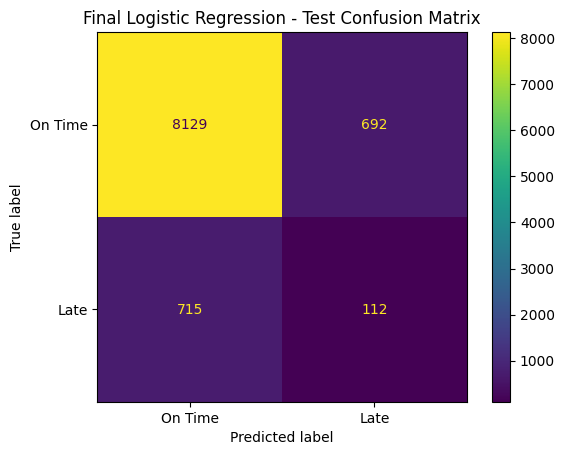

In [72]:
cm = confusion_matrix(
    y_test,
    test_pred
)

print(
    "=== CONFUSION MATRIX ==="
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "On Time",
        "Late"
    ]
)

disp.plot()

plt.title(
    "Final Logistic Regression - Test Confusion Matrix"
)

plt.show()



In [73]:
import json

with open("../artifacts/model_config.json", "w") as f:
    json.dump({
        "threshold": float(best_threshold)
    }, f)

In [74]:
results_path = (
    "../artifacts/final_test_results.csv"
)

final_results_df.to_csv(
    results_path,
    index=False
)

print(
    "Final test results saved successfully!"
)

print(
    "Path:",
    results_path
)

Final test results saved successfully!
Path: ../artifacts/final_test_results.csv


In [75]:
test_predictions = test_df[
    ["order_id"]
].copy()

test_predictions["actual_late"] = (
    y_test.values
)

test_predictions["predicted_late"] = (
    test_pred
)

test_predictions["late_probability"] = (
    test_prob
)

predictions_path = (
    "../artifacts/test_predictions.csv"
)

test_predictions.to_csv(
    predictions_path,
    index=False
)

print(
    "Test predictions saved successfully!"
)

print(
    "Path:",
    predictions_path
)


Test predictions saved successfully!
Path: ../artifacts/test_predictions.csv


In [76]:
print("\n===================================")
print("Notebook 6 completed successfully!")
print("===================================")


Notebook 6 completed successfully!
